# HW 2: Decision trees, pt 2.1

In [59]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
from sklearn import preprocessing
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn import tree
import graphviz 

%pylab inline
pylab.rcParams['figure.figsize'] = (12.0, 8.0)

Populating the interactive namespace from numpy and matplotlib


In [20]:
%load_ext pycodestyle_magic

The pycodestyle_magic extension is already loaded. To reload it, use:
  %reload_ext pycodestyle_magic


In [21]:
RARE_PERCENT = 20
STR_REG = '77|97|78'

## Data import

In [22]:
train_df = pd.read_csv("data/train.csv", index_col=0)
test_df = pd.read_csv("data/test.csv", index_col=0)

In [23]:
train_df.head()

,auto_number,auto_brand,compensated,too_much
id,,,,
269,Y418EX197RUS,Volkswagen Passat,900,1
801,8601XX154RUS,Skoda Octavia,3900,0
467,M301CH161RUS,Ford Focus,8000,0
806,Y344E877RUS,Ford Focus,1000,0
32,X286TC36RUS,Ford Focus,500,0


## Sorting out "auto_brand"

In [24]:
(train_df['auto_brand'].value_counts()/
 train_df['auto_brand'].shape[0]) * 100

Ford Focus            80.195258
Skoda Octavia          6.415621
Volkswagen Golf        2.928870
Volkswagen Passat      2.510460
Toyota Camry           2.370990
Toyota Corolla         2.231520
Volkswagen Jetta       0.836820
Ford Mondeo            0.836820
Volkswagen Touareg     0.557880
BMW                    0.418410
Volkswagen             0.418410
Audi                   0.139470
Volvo                  0.139470
Name: auto_brand, dtype: float64

Everything with percentage less than RARE_PERCENT goes to 'Rare':

In [25]:
percentage = (train_df['auto_brand'].value_counts() /
              train_df['auto_brand'].shape[0]) * 100
rare_list = train_df['auto_brand'].value_counts()[percentage <=
                                                  RARE_PERCENT].index

train_df['auto_brand'] = train_df['auto_brand'].apply(lambda x:
                                                      'Rare' if x
                                                      in rare_list else x)

(train_df['auto_brand'].value_counts()/
 train_df['auto_brand'].shape[0])*100

Ford Focus    80.195258
Rare          19.804742
Name: auto_brand, dtype: float64

In [26]:
train_df.head()

,auto_number,auto_brand,compensated,too_much
id,,,,
269,Y418EX197RUS,Rare,900,1
801,8601XX154RUS,Rare,3900,0
467,M301CH161RUS,Ford Focus,8000,0
806,Y344E877RUS,Ford Focus,1000,0
32,X286TC36RUS,Ford Focus,500,0


## Creating one-hot interpretation for "auto_brand"

In [27]:
train_df = pd.concat([train_df, pd.get_dummies(train_df['auto_brand'], 
                                               prefix='brand')], axis=1)

In [28]:
train_df.head()

,auto_number,auto_brand,compensated,too_much,brand_Ford Focus,brand_Rare
id,,,,,,
269,Y418EX197RUS,Rare,900,1,0,1
801,8601XX154RUS,Rare,3900,0,0,1
467,M301CH161RUS,Ford Focus,8000,0,1,0
806,Y344E877RUS,Ford Focus,1000,0,1,0
32,X286TC36RUS,Ford Focus,500,0,1,0


## Trying to get the region from "auto_number"

In [29]:
train_df.shape

(717, 6)

In [30]:
train_df['auto_number'].str.contains('RUS').shape

(717,)

In [31]:
regions = train_df['auto_number'].str.findall('\d+?(?=RUS)').str[0]

### Moscow region

In [33]:
regions.str.contains('77|97').sum()

336

### St Peter's

In [34]:
regions.str.contains('78').sum()

81

In [35]:
regions.value_counts()[regions.value_counts()>10]

197     163
8197     87
178      64
154      62
161      57
50       29
96       21
36       16
152      15
77       12
877      12
8161     12
Name: auto_number, dtype: int64

In [36]:
train_df['region'] = regions

In [37]:
train_df.head()

,auto_number,auto_brand,compensated,too_much,brand_Ford Focus,brand_Rare,region
id,,,,,,,
269,Y418EX197RUS,Rare,900,1,0,1,197
801,8601XX154RUS,Rare,3900,0,0,1,154
467,M301CH161RUS,Ford Focus,8000,0,1,0,161
806,Y344E877RUS,Ford Focus,1000,0,1,0,877
32,X286TC36RUS,Ford Focus,500,0,1,0,36


### Sorting just by whether the region is Moscow/St Peter's or not

In [38]:
train_df['reg_code'] = train_df['region'].str.contains(STR_REG).astype(int)

In [39]:
train_df['reg_code'].value_counts()

1    413
0    304
Name: reg_code, dtype: int64

In [40]:
train_df.head()

,auto_number,auto_brand,compensated,too_much,brand_Ford Focus,brand_Rare,region,reg_code
id,,,,,,,,
269,Y418EX197RUS,Rare,900,1,0,1,197,1
801,8601XX154RUS,Rare,3900,0,0,1,154,0
467,M301CH161RUS,Ford Focus,8000,0,1,0,161,0
806,Y344E877RUS,Ford Focus,1000,0,1,0,877,1
32,X286TC36RUS,Ford Focus,500,0,1,0,36,0


In [41]:
train_df = train_df.drop(['auto_number', 'auto_brand','region'], axis=1)

In [42]:
train_df.head()

,compensated,too_much,brand_Ford Focus,brand_Rare,reg_code
id,,,,,
269,900,1,0,1,1
801,3900,0,0,1,0
467,8000,0,1,0,0
806,1000,0,1,0,1
32,500,0,1,0,0


## Now the same for the test

In [50]:
test_df['auto_brand'] = test_df['auto_brand'].apply(lambda x: 'Rare' if x
                                                    in rare_list else x)
test_df = pd.concat([test_df, pd.get_dummies(test_df['auto_brand'],
                                             prefix='brand')], axis=1)

regions_test = test_df['auto_number'].str.findall('\d+?(?=RUS)').str[0]

test_df['reg_code'] = regions_test.str.contains(STR_REG).astype(int)

diff = set(train_df.columns) - set(test_df.columns)

for brand in diff:
    test_df[brand] = [0] * test_df.shape[0]


test_df = test_df.drop(['auto_number', 'auto_brand'], axis=1)

In [51]:
test_df.head()

,compensated,too_much,brand_Ford Focus,brand_Rare,reg_code
id,,,,,
561,3000,1,1,0,0
643,6100,1,1,0,1
657,300,0,1,0,0
630,200,0,1,0,0
596,2000,0,1,0,0


### Double-checking the dimensions

In [53]:
print(test_df.shape)
print(train_df.shape)

(100, 5)
(717, 5)


## Defining the data for classification

In [56]:
X_train, y_train, X_test, y_test = \
    train_df.loc[:, train_df.columns != 'too_much'],\
    train_df['too_much'],\
    test_df.loc[:, test_df.columns != 'too_much'],\
    test_df['too_much']

## Tree with default parameters

In [57]:
first_tree = DecisionTreeClassifier(max_depth=5, random_state=42)
first_tree.fit(X_train, y_train)

DecisionTreeClassifier(class_weight=None, criterion='gini', max_depth=5,
                       max_features=None, max_leaf_nodes=None,
                       min_impurity_decrease=0.0, min_impurity_split=None,
                       min_samples_leaf=1, min_samples_split=2,
                       min_weight_fraction_leaf=0.0, presort=False,
                       random_state=42, splitter='best')

In [58]:
predictions = first_tree.predict_proba(X_test)[:, 1]
print(roc_auc_score(y_test, predictions))

0.6797979797979797


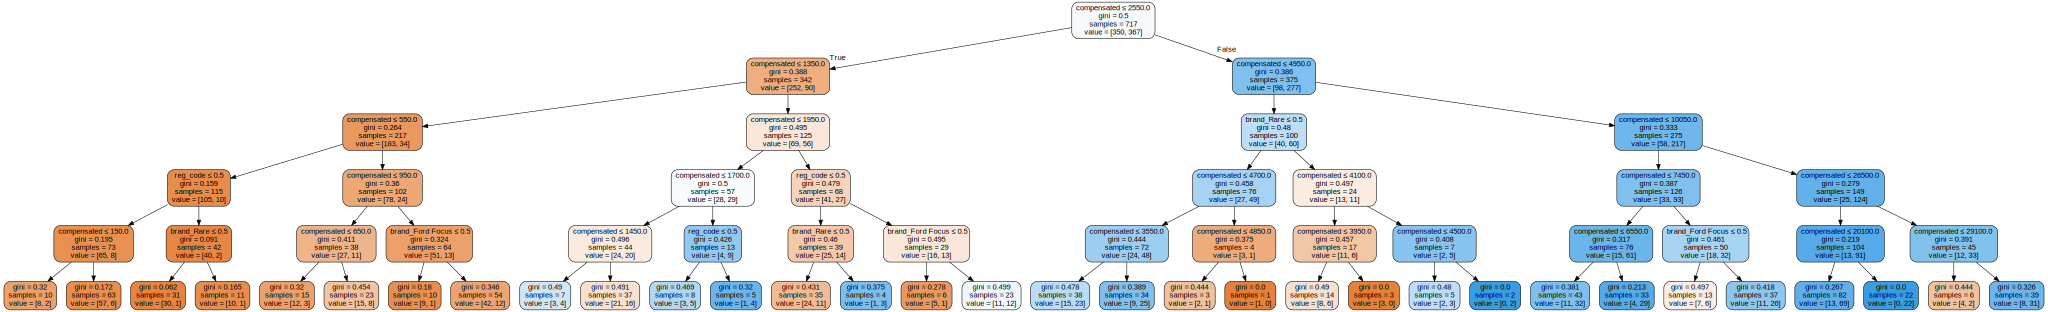

In [60]:
dot_data = tree.export_graphviz(first_tree, out_file=None,
                                feature_names=X_train.columns,
                                filled=True, rounded=True,
                                special_characters=True)  
graphviz.Source(dot_data)  

In [63]:
# tree params for grid search
tree_params = {
    'criterion': ['gini', 'entropy'],
    'max_depth': list(range(2, 10)),
    'min_samples_leaf': list(range(5, 11))
}

locally_best_tree = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    tree_params,
    verbose=True,
    n_jobs=-1,
    cv=5, scoring='roc_auc'
)
locally_best_tree.fit(X_train, y_train)

print(locally_best_tree.best_score_)
print(locally_best_tree.best_params_)

Fitting 5 folds for each of 96 candidates, totalling 480 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    1.6s


0.7783485251416702
{'criterion': 'gini', 'max_depth': 4, 'min_samples_leaf': 10}


[Parallel(n_jobs=-1)]: Done 480 out of 480 | elapsed:    2.2s finished


In [64]:
X_train.columns[locally_best_tree.best_estimator_.feature_importances_ != 0]

Index(['compensated', 'brand_Ford Focus', 'reg_code'], dtype='object')

In [65]:
predictions = locally_best_tree.predict_proba(X_test)[:, 1]
print(roc_auc_score(y_test, predictions))

0.6652525252525252


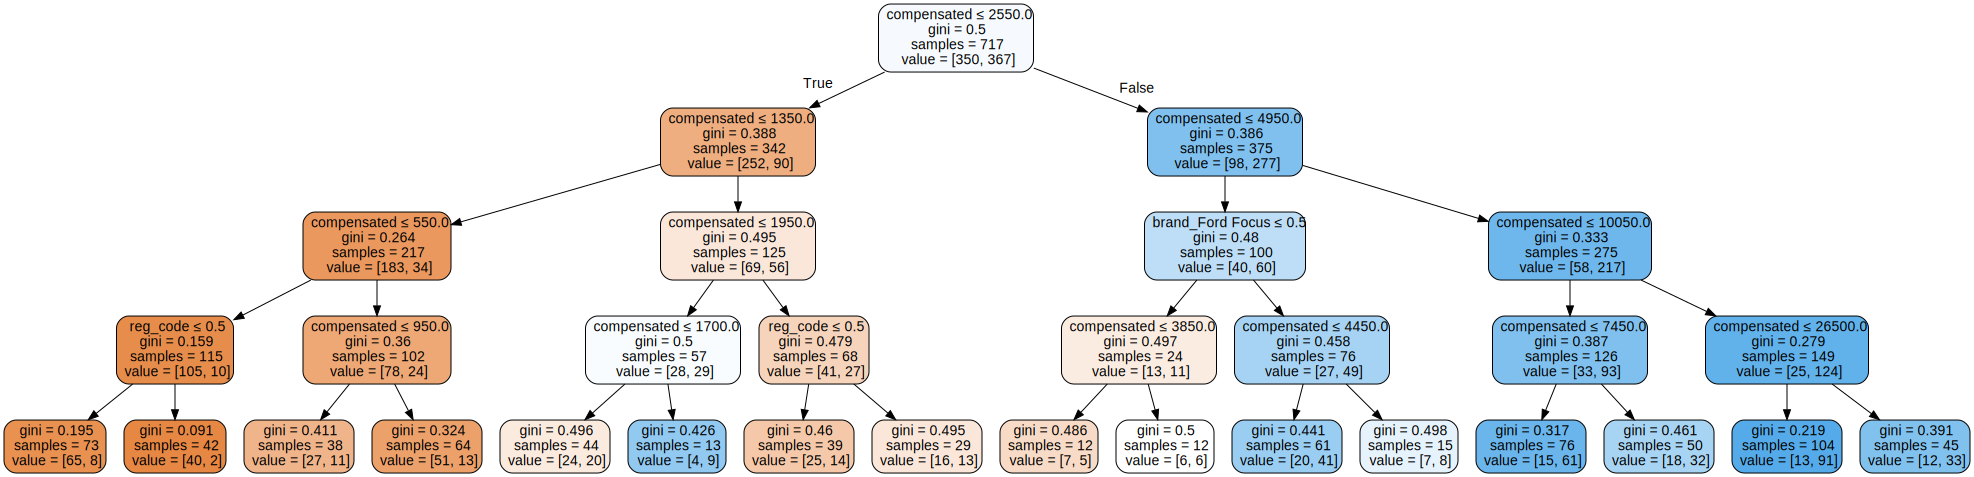

In [66]:
dot_data = tree.export_graphviz(locally_best_tree.best_estimator_, out_file=None, 
                     feature_names=X_train.columns,  
                     filled=True, rounded=True,  
                     special_characters=True)  

graph = graphviz.Source(dot_data)  
graph.render(filename='insurance_tree_tuned')
graph

### The code above can be easily ran with different values of RARE_PERCENT (it doesn't change the final score much, though)